In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import *


%matplotlib inline

In [2]:
df= pd.read_excel(r'C:\Users\HP\Downloads\Development Data (Autosaved).xlsx')
df.head()

,LoanId,AccountState,AccountSubstate,Product,CreationDate,DisbursementDate,DisbMonth,InitialDecision,InitialDecisionCode,ReasonCode_01,...,EarlySettlementFlg,WeekDay,DayOfTheMonth,timeindayselect,FirstRD,FirstDD,InterestRate,Acct_Duratn,Unnamed: 40,Unnamed: 41
0,1,CLOSED,NaN,Self Employed Seasoned - Weekly,2021-12-02,2021-12-06,2021-12-01,2021-12-03,Accept,NaN,...,1,Thursday,2,8am - 10am,2022-02-08 00:00:00,2022-01-03,7.02,NaN,NaN,NaN
1,2,CLOSED_REJECTED,NaN,Self Employed - Weekly New,2021-12-02,NaT,NaT,2021-12-02,Accept,NaN,...,0,Thursday,2,8am - 10am,NaN,2021-12-30,9.18,2019-04-01 00:00:00,NaN,NaN
2,3,CLOSED,WITHDRAWN,Self Employed - Weekly New,2021-12-02,NaT,NaT,2021-12-02,Accept,High Existing Exposure,...,0,Thursday,2,8am - 10am,NaN,2021-12-31,10.65,NaN,NaN,NaN
3,4,ACTIVE_IN_ARREARS,NaN,Self Employed Seasoned - Weekly,2021-12-02,2021-12-03,2021-12-01,2021-12-02,Accept,Application accepted in last 3 months,...,0,Thursday,2,10am - 12pm,NaN,2021-12-31,7.02,2007-10-01 00:00:00,NaN,NaN
4,5,CLOSED,WITHDRAWN,Self Employed - Weekly New,2021-12-02,NaT,NaT,2021-12-02,Accept,NaN,...,0,Thursday,2,10am - 12pm,NaN,2021-12-30,9.18,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61882 entries, 0 to 61881
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   LoanId               61882 non-null  int64         
 1   AccountState         61882 non-null  object        
 2   AccountSubstate      31606 non-null  object        
 3   Product              61882 non-null  object        
 4   CreationDate         61882 non-null  datetime64[ns]
 5   DisbursementDate     7439 non-null   datetime64[ns]
 6   DisbMonth            7439 non-null   datetime64[ns]
 7   InitialDecision      61882 non-null  datetime64[ns]
 8   InitialDecisionCode  61882 non-null  object        
 9   ReasonCode_01        13630 non-null  object        
 10  Age                  61882 non-null  object        
 11  DocumentType         61809 non-null  object        
 12  DTI                  61882 non-null  object        
 13  EducationStatus      61882 non-

In [4]:
df.columns

Index(['LoanId', 'AccountState', 'AccountSubstate', 'Product', 'CreationDate',
       'DisbursementDate', 'DisbMonth', 'InitialDecision',
       'InitialDecisionCode', 'ReasonCode_01', 'Age', 'DocumentType', 'DTI',
       'EducationStatus', 'EmployerLGA', 'EmployerState', 'Gender', 'Income',
       'Industry', 'LoanAmount', 'MaritalStatus', 'NoChildren',
       'ResidentialStatus', 'Term', 'TimeEmploymentMM', 'TotalTimeAtAddress',
       'BusinessSector', 'EmploymentPosition', 'MaxDPD', '(DueDate) FPD',
       'Closeddate', 'MaturityDate', 'EarlySettlementFlg', 'WeekDay',
       'DayOfTheMonth', 'timeindayselect', 'FirstRD', 'FirstDD',
       'InterestRate', 'Acct_Duratn', 'Unnamed: 40', 'Unnamed: 41'],
      dtype='object')

In [5]:
df = df.drop(['Product', 'CreationDate', 'DocumentType', 'Unnamed: 40', 'Unnamed: 41', 'InitialDecision', 'InitialDecisionCode', 'ReasonCode_01', 'EmployerLGA', 'DTI','Term', 'EmploymentPosition', '(DueDate) FPD', 'Closeddate', 'MaturityDate', 'EarlySettlementFlg', 'WeekDay', 'DayOfTheMonth', 'timeindayselect', 'FirstRD', 'FirstDD', 'InterestRate', 'Acct_Duratn'], axis=1)
df.head()

,LoanId,AccountState,AccountSubstate,DisbursementDate,DisbMonth,Age,EducationStatus,EmployerState,Gender,Income,Industry,LoanAmount,MaritalStatus,NoChildren,ResidentialStatus,TimeEmploymentMM,TotalTimeAtAddress,BusinessSector,MaxDPD
0,1,CLOSED,NaN,2021-12-06,2021-12-01,49,Graduate,Lagos,MALE,17385295,Construction,2000000,Married,1,Renting,187,148.0,Construction,1
1,2,CLOSED_REJECTED,NaN,NaT,NaT,37,Post Graduate,FCT,MALE,5000000,Consumer Goods,1000000,Married,3,Renting,30,58.0,Consumer Goods,NaN
2,3,CLOSED,WITHDRAWN,NaT,NaT,40,Graduate,Edo,MALE,20000000,Wholesale and retail trade,600000,Married,0,Renting,68,122.0,Wholesale and retail trade,NaN
3,4,ACTIVE_IN_ARREARS,NaN,2021-12-03,2021-12-01,35,Graduate,Lagos,MALE,8179444.33,Human health and social work activities,3000000,Married,0,Renting,52,104.0,Human health and social work activities,123
4,5,CLOSED,WITHDRAWN,NaT,NaT,60,Graduate,Ogun,FEMALE,12000000,Consumer Goods,1500000,Married,0,Owner,114,251.0,Consumer Goods,NaN


In [6]:
df.describe()

,LoanId,DisbursementDate,DisbMonth,TotalTimeAtAddress
count,61882.000000,7439,7439,61725.000000
mean,30941.500000,2022-04-24 11:38:59.830622464,2022-04-08 11:08:59.588654592,170.255245
min,1.000000,2021-08-30 00:00:00,2021-08-01 00:00:00,-999.000000
25%,15471.250000,2022-01-25 00:00:00,2022-01-01 00:00:00,72.000000
50%,30941.500000,2022-04-25 00:00:00,2022-04-01 00:00:00,125.000000
75%,46411.750000,2022-08-20 00:00:00,2022-08-01 00:00:00,270.000000
max,61882.000000,2022-11-15 00:00:00,2022-11-01 00:00:00,1852.000000
std,17863.939016,NaN,NaN,328.879807


In [7]:
non_int_age_rows = df[df['Age'].apply(type) != int]
non_int_age_rows


,LoanId,AccountState,AccountSubstate,DisbursementDate,DisbMonth,Age,EducationStatus,EmployerState,Gender,Income,Industry,LoanAmount,MaritalStatus,NoChildren,ResidentialStatus,TimeEmploymentMM,TotalTimeAtAddress,BusinessSector,MaxDPD
185,186,CLOSED,WITHDRAWN,NaT,NaT,"Outside Approved Areas]""",0,Aguata,Anambra,MALE,10000000,Services,2000000,Single,Aguata,12,-999.0,-999,NaN
187,188,CLOSED,WITHDRAWN,NaT,NaT,"Outside Approved Areas]""",0,Owerri Municipal,Imo,MALE,1000000,Agriculture,223740,Married,Owerri Municipal,12,-999.0,-999,NaN
270,271,CLOSED,WITHDRAWN,NaT,NaT,"Outside Approved Areas]""",0,Aba South,Abia,MALE,1500000,Wholesale and retail trade,290862,Married,Aba South,12,-999.0,-999,NaN
274,275,CLOSED,WITHDRAWN,NaT,NaT,"Outside Approved Areas]""",0,Akure South,Ondo,MALE,1000000,Human health and social work activities,223740,Married,Makurdi,12,-999.0,-999,NaN
277,278,CLOSED,WITHDRAWN,NaT,NaT,"Outside Approved Areas]""",0,Gwagwalada,FCT,FEMALE,1000000,Information and communication,223740,Single,Abakaliki,12,-999.0,-999,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61827,61828,CLOSED_REJECTED,NaN,NaT,NaT,"Outside Approved Areas]""",0,Ajaokuta,Kogi,MALE,300000,Consumer Goods,218323,Married,Okene,12,-999.0,-999,Good
61835,61836,CLOSED,WITHDRAWN,NaT,NaT,"Outside Approved Areas]""",0,Enugu North,Enugu,MALE,800000,Wholesale and retail trade,100000,Single,Enugu North,12,-999.0,-999,Good
61836,61837,CLOSED,WITHDRAWN,NaT,NaT,"Outside Approved Areas]""",0,Fufure,Adamawa,MALE,50000000,Information and communication,3000000,Married,Fufore,12,-999.0,-999,Good
61852,61853,CLOSED,WITHDRAWN,NaT,NaT,"Outside Approved Areas]""",0,Atiba,Oyo,MALE,900000,Agriculture,196491,Married,Atiba,12,-999.0,-999,Good


In [8]:
int_age_rows= df[df['Age'].apply(type) == int]
int_age_rows


,LoanId,AccountState,AccountSubstate,DisbursementDate,DisbMonth,Age,EducationStatus,EmployerState,Gender,Income,Industry,LoanAmount,MaritalStatus,NoChildren,ResidentialStatus,TimeEmploymentMM,TotalTimeAtAddress,BusinessSector,MaxDPD
0,1,CLOSED,NaN,2021-12-06,2021-12-01,49,Graduate,Lagos,MALE,17385295,Construction,2000000,Married,1,Renting,187,148.0,Construction,1
1,2,CLOSED_REJECTED,NaN,NaT,NaT,37,Post Graduate,FCT,MALE,5000000,Consumer Goods,1000000,Married,3,Renting,30,58.0,Consumer Goods,NaN
2,3,CLOSED,WITHDRAWN,NaT,NaT,40,Graduate,Edo,MALE,20000000,Wholesale and retail trade,600000,Married,0,Renting,68,122.0,Wholesale and retail trade,NaN
3,4,ACTIVE_IN_ARREARS,NaN,2021-12-03,2021-12-01,35,Graduate,Lagos,MALE,8179444.33,Human health and social work activities,3000000,Married,0,Renting,52,104.0,Human health and social work activities,123
4,5,CLOSED,WITHDRAWN,NaT,NaT,60,Graduate,Ogun,FEMALE,12000000,Consumer Goods,1500000,Married,0,Owner,114,251.0,Consumer Goods,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61876,61877,CLOSED,WITHDRAWN,NaT,NaT,40,Graduate,FCT,FEMALE,10000000,Services,1900000,Married,1,Owner,175,246.0,Services,NaN
61877,61878,CLOSED_REJECTED,NaN,NaT,NaT,34,Graduate,Lagos,FEMALE,20000000,"Arts, entertainment and recreation",3000000,Married,2,Renting,78,168.0,"Arts, entertainment and recreation",NaN
61878,61879,CLOSED_REJECTED,NaN,NaT,NaT,32,Graduate,FCT,MALE,9000000,Consumer Goods,2000000,Single,3,Renting,103,248.0,Consumer Goods,NaN
61879,61880,CLOSED,WITHDRAWN,NaT,NaT,26,Secondary,Lagos,MALE,600000,Construction,100000,Married,1,Renting,167,291.0,Construction,NaN


In [9]:
int_age_rows['EmployerState'].unique()

array(['Lagos', 'FCT', 'Edo', 'Ogun', 'Rivers', 'Oyo', 'Akwa Ibom',
       'Kano', 'Kogi', 'Kwara', 'Cross River', 'Ondo', 'Delta', 'Ebonyi',
       'Osun', 'Nasarawa', 'Ekiti', 'Kaduna', 'Yobe', 'Plateau', 'Abia',
       'Niger', 'Zamfara', 'Imo', 'Sokoto', 'Enugu', 'Anambra', nan,
       'Adamawa', 'Jigawa', 'Gombe', 'Bayelsa', 'Benue', 'Borno', 'Kebbi',
       'Katsina', 'Taraba', 'Bauchi'], dtype=object)

In [10]:
df= int_age_rows.copy()

In [11]:
#In Nigeria, the legal age for financial transactions is 18 years.
#To check for invalid ages we would investigate if there are any customers below 18 years of age.
if df.Age.min() < 18:
    print("There are customers below 18 years of age.")
else:
    print("All customers are above 18 years of age.")

There are customers below 18 years of age.


In [12]:
invalid_ages = df[df['Age'] < 18] 
print(f"Invalid ages found: {len(invalid_ages)}")

Invalid ages found: 87


In [13]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'].describe()

count    59416.000000
mean        35.522805
std          8.770926
min        -46.000000
25%         29.000000
50%         34.000000
75%         41.000000
max         76.000000
Name: Age, dtype: float64

Text(0.5, 1.0, 'Age Distribution of Customers')

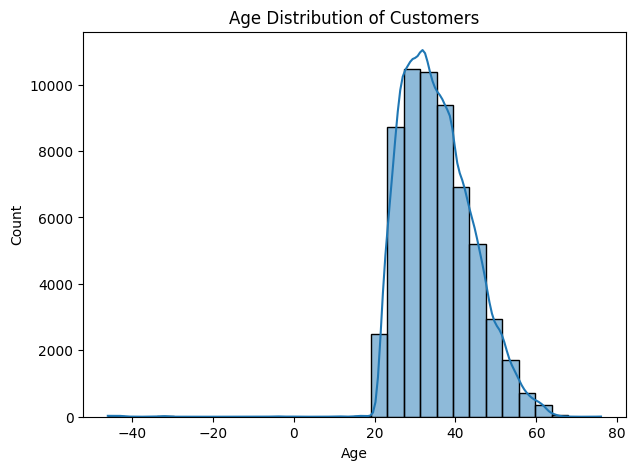

In [14]:
plt.figure(figsize=(7, 5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Customers')

In [15]:
#for rows where age is less than 0, the rows will be dropped
#for rows where age is between 0 and 17 inclusive, the ages will be replaced with median

#dropping rows where age<0
df=df[df['Age']>= 0].reset_index(drop=True)

#calculating the median age
median_age = df['Age'].median()

#loop to replace ages between 0 and 17
for i in range(len(df)):
    if 0<= df.loc[i, 'Age']<=17:
        df.loc[i, 'Age'] = median_age

df.head()
        

,LoanId,AccountState,AccountSubstate,DisbursementDate,DisbMonth,Age,EducationStatus,EmployerState,Gender,Income,Industry,LoanAmount,MaritalStatus,NoChildren,ResidentialStatus,TimeEmploymentMM,TotalTimeAtAddress,BusinessSector,MaxDPD
0,1,CLOSED,NaN,2021-12-06,2021-12-01,49,Graduate,Lagos,MALE,17385295,Construction,2000000,Married,1,Renting,187,148.0,Construction,1
1,2,CLOSED_REJECTED,NaN,NaT,NaT,37,Post Graduate,FCT,MALE,5000000,Consumer Goods,1000000,Married,3,Renting,30,58.0,Consumer Goods,NaN
2,3,CLOSED,WITHDRAWN,NaT,NaT,40,Graduate,Edo,MALE,20000000,Wholesale and retail trade,600000,Married,0,Renting,68,122.0,Wholesale and retail trade,NaN
3,4,ACTIVE_IN_ARREARS,NaN,2021-12-03,2021-12-01,35,Graduate,Lagos,MALE,8179444.33,Human health and social work activities,3000000,Married,0,Renting,52,104.0,Human health and social work activities,123
4,5,CLOSED,WITHDRAWN,NaT,NaT,60,Graduate,Ogun,FEMALE,12000000,Consumer Goods,1500000,Married,0,Owner,114,251.0,Consumer Goods,NaN


In [16]:
#now to investigate the distribution of the cleaned age column in the new dataframe
df['Age'].describe()

count    59358.000000
mean        35.601890
std          8.465817
min         18.000000
25%         29.000000
50%         34.000000
75%         41.000000
max         76.000000
Name: Age, dtype: float64

Text(0.5, 1.0, 'Age Distribution of Customers')

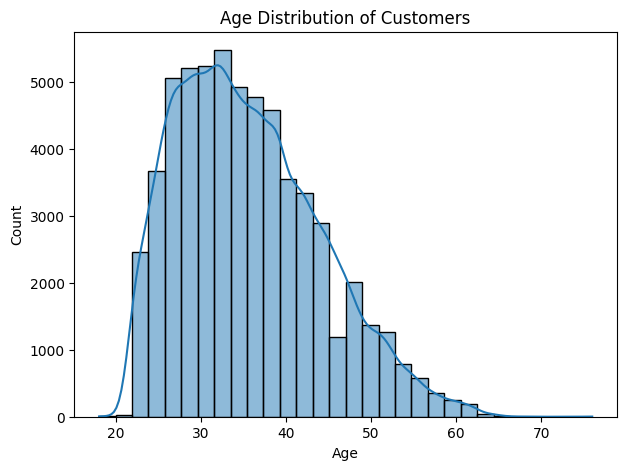

In [17]:
plt.figure(figsize=(7,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Customers')

In [18]:
df.head()

,LoanId,AccountState,AccountSubstate,DisbursementDate,DisbMonth,Age,EducationStatus,EmployerState,Gender,Income,Industry,LoanAmount,MaritalStatus,NoChildren,ResidentialStatus,TimeEmploymentMM,TotalTimeAtAddress,BusinessSector,MaxDPD
0,1,CLOSED,NaN,2021-12-06,2021-12-01,49,Graduate,Lagos,MALE,17385295,Construction,2000000,Married,1,Renting,187,148.0,Construction,1
1,2,CLOSED_REJECTED,NaN,NaT,NaT,37,Post Graduate,FCT,MALE,5000000,Consumer Goods,1000000,Married,3,Renting,30,58.0,Consumer Goods,NaN
2,3,CLOSED,WITHDRAWN,NaT,NaT,40,Graduate,Edo,MALE,20000000,Wholesale and retail trade,600000,Married,0,Renting,68,122.0,Wholesale and retail trade,NaN
3,4,ACTIVE_IN_ARREARS,NaN,2021-12-03,2021-12-01,35,Graduate,Lagos,MALE,8179444.33,Human health and social work activities,3000000,Married,0,Renting,52,104.0,Human health and social work activities,123
4,5,CLOSED,WITHDRAWN,NaT,NaT,60,Graduate,Ogun,FEMALE,12000000,Consumer Goods,1500000,Married,0,Owner,114,251.0,Consumer Goods,NaN


In [19]:
df.columns

Index(['LoanId', 'AccountState', 'AccountSubstate', 'DisbursementDate',
       'DisbMonth', 'Age', 'EducationStatus', 'EmployerState', 'Gender',
       'Income', 'Industry', 'LoanAmount', 'MaritalStatus', 'NoChildren',
       'ResidentialStatus', 'TimeEmploymentMM', 'TotalTimeAtAddress',
       'BusinessSector', 'MaxDPD'],
      dtype='object')

In [20]:
df['AccountState']= df['AccountState'].fillna('NULL')
df['AccountSubstate']= df['AccountSubstate'].fillna('NULL')
df['DisbMonth']= df['DisbMonth'].fillna('NULL')
df['DisbursementDate']= df['DisbursementDate'].fillna('NULL')

In [21]:
missing_rows = df[df.isnull().any(axis=1)]
missing_rows

,LoanId,AccountState,AccountSubstate,DisbursementDate,DisbMonth,Age,EducationStatus,EmployerState,Gender,Income,Industry,LoanAmount,MaritalStatus,NoChildren,ResidentialStatus,TimeEmploymentMM,TotalTimeAtAddress,BusinessSector,MaxDPD
1,2,CLOSED_REJECTED,NULL,NULL,NULL,37,Post Graduate,FCT,MALE,5000000,Consumer Goods,1000000,Married,3,Renting,30,58.0,Consumer Goods,NaN
2,3,CLOSED,WITHDRAWN,NULL,NULL,40,Graduate,Edo,MALE,20000000,Wholesale and retail trade,600000,Married,0,Renting,68,122.0,Wholesale and retail trade,NaN
4,5,CLOSED,WITHDRAWN,NULL,NULL,60,Graduate,Ogun,FEMALE,12000000,Consumer Goods,1500000,Married,0,Owner,114,251.0,Consumer Goods,NaN
6,7,CLOSED,WITHDRAWN,NULL,NULL,35,Graduate,Lagos,MALE,5000000,Transportation and storage,1100000,Married,0,Renting,44,51.0,Transportation and storage,NaN
7,8,CLOSED,WITHDRAWN,NULL,NULL,35,Graduate,Lagos,MALE,5000000,Transportation and storage,1100000,Married,0,Renting,44,51.0,Transportation and storage,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59353,61877,CLOSED,WITHDRAWN,NULL,NULL,40,Graduate,FCT,FEMALE,10000000,Services,1900000,Married,1,Owner,175,246.0,Services,NaN
59354,61878,CLOSED_REJECTED,NULL,NULL,NULL,34,Graduate,Lagos,FEMALE,20000000,"Arts, entertainment and recreation",3000000,Married,2,Renting,78,168.0,"Arts, entertainment and recreation",NaN
59355,61879,CLOSED_REJECTED,NULL,NULL,NULL,32,Graduate,FCT,MALE,9000000,Consumer Goods,2000000,Single,3,Renting,103,248.0,Consumer Goods,NaN
59356,61880,CLOSED,WITHDRAWN,NULL,NULL,26,Secondary,Lagos,MALE,600000,Construction,100000,Married,1,Renting,167,291.0,Construction,NaN


In [22]:
for i in ['AccountState', 'AccountSubstate']:
    print(f'unique values in {i} are: {df[i].unique()}', '\n')

unique values in AccountState are: ['CLOSED' 'CLOSED_REJECTED' 'ACTIVE_IN_ARREARS' 'CLOSED_WRITTEN_OFF'
 'APPROVED' 'ACTIVE' 'PARTIAL_APPLICATION' 'PENDING_APPROVAL'] 

unique values in AccountSubstate are: ['NULL' 'WITHDRAWN' 'LOCKED'] 



In [23]:
def classify_default(row):
    account_state = row['AccountState']
    account_substate = row['AccountSubstate']
    max_dpd = row['MaxDPD']
    disb_date = row['DisbursementDate']
    disb_month = row['DisbMonth']
    
    # 1. Fully repaid loan
    if account_state == 'CLOSED' and account_substate== 'NULL':
        return 'no'
    
    # 2. Totally defaulted
    elif account_state == 'CLOSED_WRITTEN_OFF' and account_substate == 'NULL':
        return 'yes'
    
    # Totally defaulted
    elif account_state == 'CLOSED_WRITTEN_OFF' and account_substate == 'LOCKED':
        return 'yes'
    
    # 5. Loan is active but in arrears → defaulted
    elif account_state == 'ACTIVE_IN_ARREARS' and account_substate == 'NULL':
        return 'yes'
    
    elif account_state == 'ACTIVE':
        return 'yes'
    
    # 6. MaxDPD ≥ 90 → considered defaulted
    if pd.to_numeric(max_dpd, errors='coerce') >= 90:
        return 'yes'
    
    # 7. All other cases
    else:
        return 'Unknown'

# Apply the function row by row
df['DefaultStatus'] = df.apply(classify_default, axis=1)

In [24]:
df= df.drop(['AccountState', 'AccountSubstate', 'MaxDPD', 'DisbursementDate', 'DisbMonth' ], axis=1)
df.columns

Index(['LoanId', 'Age', 'EducationStatus', 'EmployerState', 'Gender', 'Income',
       'Industry', 'LoanAmount', 'MaritalStatus', 'NoChildren',
       'ResidentialStatus', 'TimeEmploymentMM', 'TotalTimeAtAddress',
       'BusinessSector', 'DefaultStatus'],
      dtype='object')

In [25]:
df['DefaultStatus'].value_counts()

DefaultStatus
Unknown    51922
yes         4843
no          2593
Name: count, dtype: int64

In [26]:
for i in df.columns:
    print(f"the data type of '{i}' is: {df[i].dtype}", '\n')

the data type of 'LoanId' is: int64 

the data type of 'Age' is: int64 

the data type of 'EducationStatus' is: object 

the data type of 'EmployerState' is: object 

the data type of 'Gender' is: object 

the data type of 'Income' is: object 

the data type of 'Industry' is: object 

the data type of 'LoanAmount' is: object 

the data type of 'MaritalStatus' is: object 

the data type of 'NoChildren' is: object 

the data type of 'ResidentialStatus' is: object 

the data type of 'TimeEmploymentMM' is: object 

the data type of 'TotalTimeAtAddress' is: float64 

the data type of 'BusinessSector' is: object 

the data type of 'DefaultStatus' is: object 



In [27]:
df['TotalTimeAtAddress'].describe()


count    59201.000000
mean       218.942788
std        231.080030
min         -9.000000
25%         74.000000
50%        127.000000
75%        274.000000
max       1852.000000
Name: TotalTimeAtAddress, dtype: float64

In [28]:
invalid_addresstime = df[df['TotalTimeAtAddress'] < 0] 
print(f"Invalids found: {len(invalid_addresstime)}")

Invalids found: 48


In [29]:
#dropping invalid times
df=df[df['TotalTimeAtAddress']>= 0].reset_index(drop=True)

In [30]:
df = df.astype({
    'LoanId': 'category',
    'Age': 'int',
    'EducationStatus': 'category',
    'EmployerState': 'category',
    'Gender': 'category',
    'Income': 'float',
    'Industry': 'category',
    'LoanAmount': 'float',
    'MaritalStatus': 'category',
    'NoChildren': 'int',
    'ResidentialStatus': 'category',
    'TimeEmploymentMM': 'int',
    'TotalTimeAtAddress': 'int',
    'BusinessSector': 'category',

})


In [31]:
df.describe()

,Age,Income,LoanAmount,NoChildren,TimeEmploymentMM,TotalTimeAtAddress
count,59153.000000,5.915100e+04,5.915300e+04,5.915300e+04,59153.000000,59153.000000
mean,35.603655,2.584645e+10,1.040666e+06,1.373228e+05,92.587933,219.124085
std,8.462489,3.561119e+12,9.491372e+05,3.339845e+07,124.725345,231.086061
min,18.000000,-1.194000e+06,1.000000e+05,0.000000e+00,-10.000000,0.000000
25%,29.000000,1.000000e+06,3.000000e+05,0.000000e+00,41.000000,74.000000
50%,34.000000,3.000000e+06,6.200000e+05,1.000000e+00,70.000000,127.000000
75%,41.000000,7.000000e+06,1.500000e+06,2.000000e+00,123.000000,274.000000
max,76.000000,5.000000e+14,5.000000e+06,8.122966e+09,23926.000000,1852.000000


In [32]:
final_df= df[df['DefaultStatus']!= 'Unknown'].copy()
final_df

,LoanId,Age,EducationStatus,EmployerState,Gender,Income,Industry,LoanAmount,MaritalStatus,NoChildren,ResidentialStatus,TimeEmploymentMM,TotalTimeAtAddress,BusinessSector,DefaultStatus
0,1,49,Graduate,Lagos,MALE,17385295.00,Construction,2000000.0,Married,1,Renting,187,148,Construction,no
3,4,35,Graduate,Lagos,MALE,8179444.33,Human health and social work activities,3000000.0,Married,0,Renting,52,104,Human health and social work activities,yes
5,6,56,Post Graduate,Lagos,MALE,1773000.00,Agriculture,750000.0,Married,2,Owner,301,312,Agriculture,no
13,14,42,Post Graduate,Lagos,MALE,5097817.67,Finance,3000000.0,Married,2,Renting,63,172,Finance,no
14,15,39,Graduate,Lagos,MALE,3146704.50,Construction,650000.0,Single,3,Renting,160,192,Construction,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59052,61768,37,Secondary,Lagos,FEMALE,602650.00,Online,110000.0,Single,1,With Relatives,61,894,Online,yes
59053,61769,37,Secondary,Lagos,FEMALE,602650.00,Online,110000.0,Single,1,With Relatives,61,894,Online,yes
59068,61787,58,Post Graduate,Lagos,MALE,9000000.00,Manufacturing,160000.0,Divorced,0,Renting,75,8,Manufacturing,yes
59117,61845,27,Graduate,Lagos,FEMALE,3000000.00,Consumer Goods,300000.0,Single,2,Owner,61,127,Consumer Goods,yes


In [33]:
final_df['DefaultStatus'].value_counts()

DefaultStatus
yes    4817
no     2592
Name: count, dtype: int64

In [34]:
final_df.columns

Index(['LoanId', 'Age', 'EducationStatus', 'EmployerState', 'Gender', 'Income',
       'Industry', 'LoanAmount', 'MaritalStatus', 'NoChildren',
       'ResidentialStatus', 'TimeEmploymentMM', 'TotalTimeAtAddress',
       'BusinessSector', 'DefaultStatus'],
      dtype='object')

Text(0.5, 1.0, 'Income Distribution of Customers')

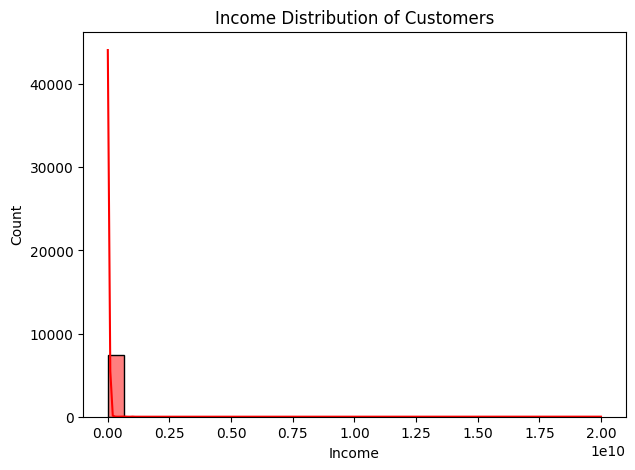

In [35]:
plt.figure(figsize=(7,5))
sns.histplot(final_df['Income'], bins=30, kde=True, color='red')
plt.title('Income Distribution of Customers')

In [36]:
# Numerical columns
numerical_columns = [
    'Age', 'Income', 'LoanAmount',
    'TimeEmploymentMM', 'TotalTimeAtAddress'
]

# Categorical columns (excluding 'LoanId' which is just an identifier)
categorical_columns = [
    'EducationStatus', 'EmployerState', 'Gender', 'Industry',
    'MaritalStatus', 'NoChildren', 'ResidentialStatus', 'BusinessSector'
]

# drop 'LoanId' before modeling
final_df = final_df.drop(columns=['LoanId', 'BusinessSector'])

# convert default status to binary
final_df['DefaultStatus'] = final_df['DefaultStatus'].map({'yes': 1, 'no': 0})

#addition of extra features
final_df['LoanPerIncome'] = final_df['LoanAmount'] / (final_df['Income'] + 1)
final_df['LoanToEmployment'] = final_df['LoanAmount'] / (final_df['TimeEmploymentMM'] + 1)

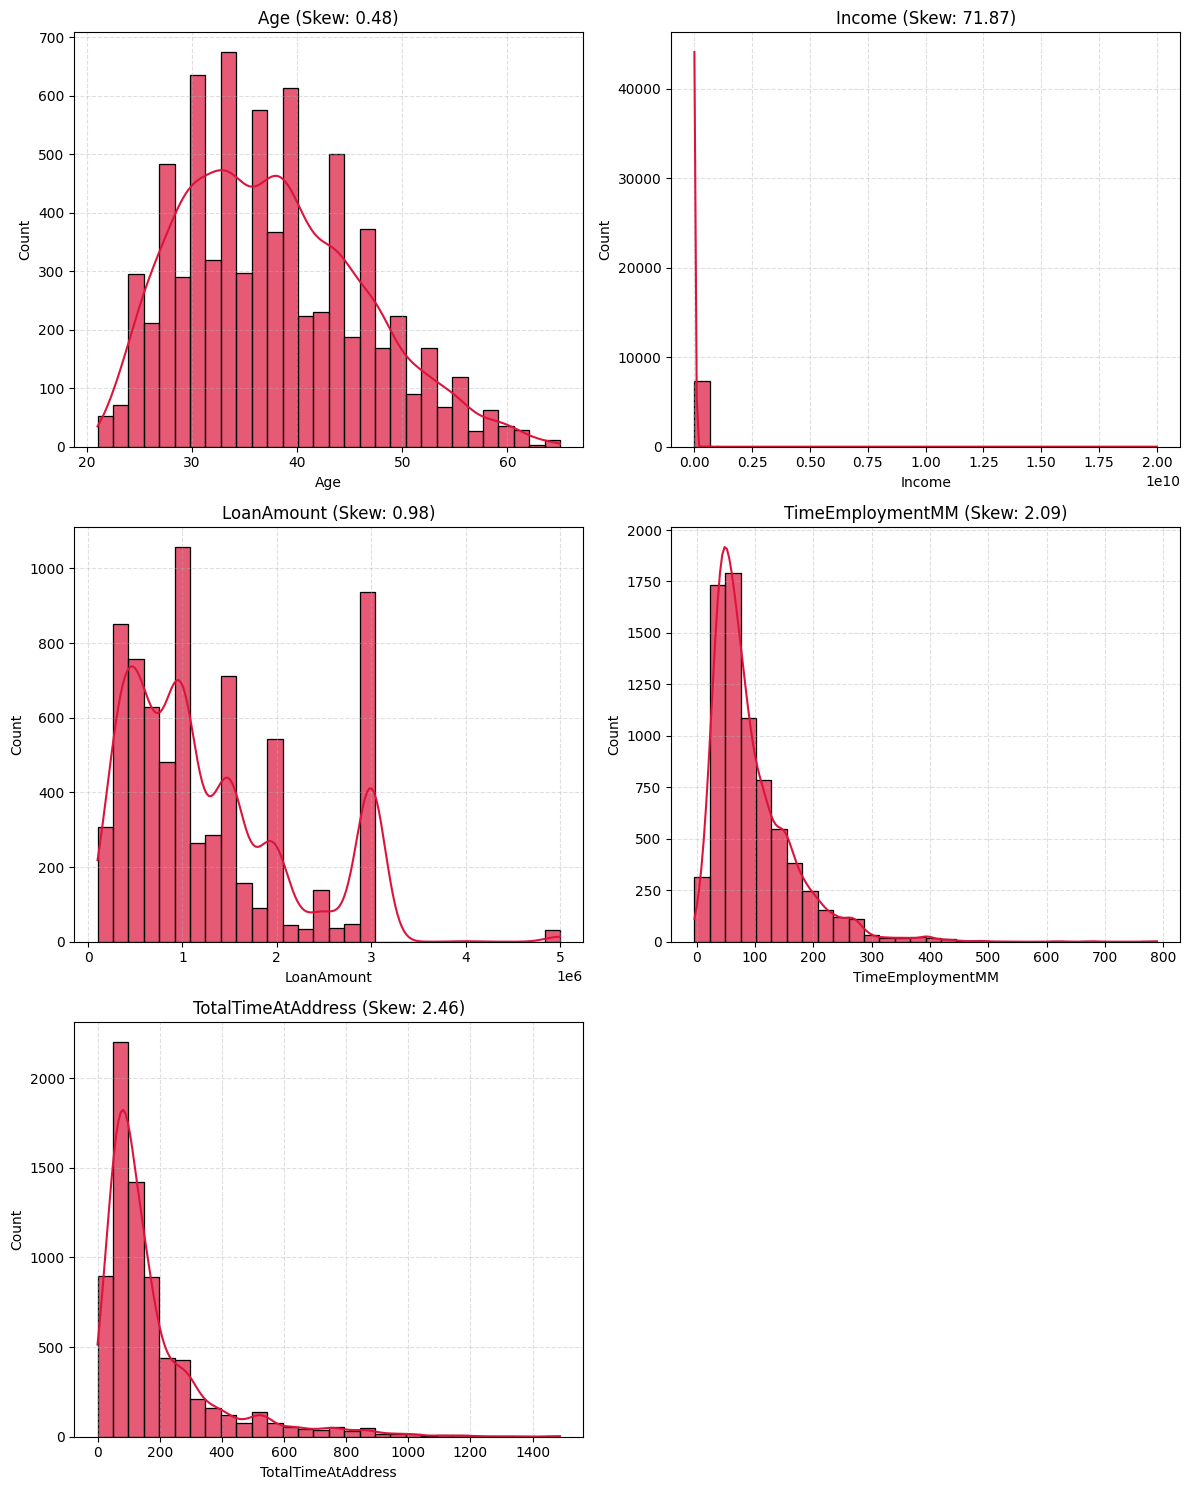

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import math

# Set up the subplot grid
num_features = len(numerical_columns)
cols = 2  # Number of columns in the grid
rows = math.ceil(num_features / cols)

plt.figure(figsize=(12, 5 * rows))  # Adjust overall figure size

for idx, feature in enumerate(numerical_columns):
    plt.subplot(rows, cols, idx + 1)
    sns.histplot(final_df[feature].dropna(), bins=30, kde=True, color='crimson', edgecolor='black', alpha=0.7)
    
    # Compute skewness
    skewness_value = skew(final_df[feature].dropna())
    
    plt.title(f'{feature} (Skew: {skewness_value:.2f})', fontsize=12)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [38]:
import numpy as np

# Copy original df
final_df= final_df.copy()

# Fix skewed columns except for 'Age' and 'LoanAmount'
columns_to_fix = ['Income', 'TimeEmploymentMM', 'TotalTimeAtAddress']

for col in columns_to_fix:
    # Avoid error with zero/negative values by using log1p
    final_df[col] = np.log1p(final_df[col])


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


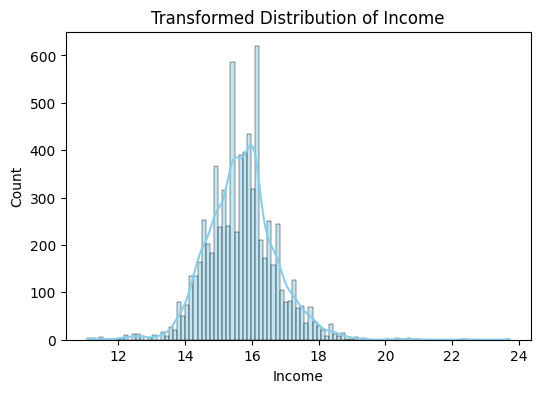

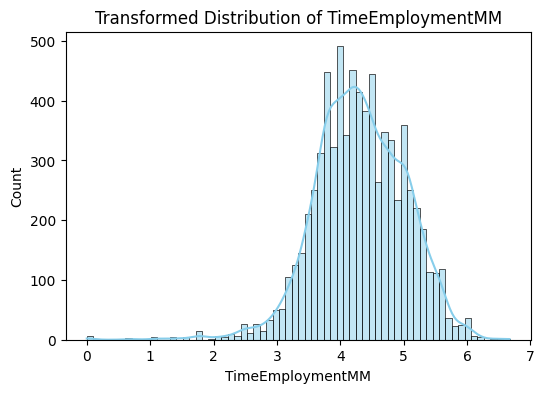

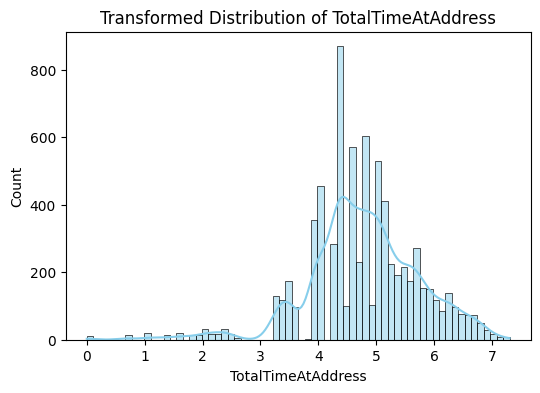

Skewness of Income after transformation: 0.26
Skewness of TimeEmploymentMM after transformation: nan
Skewness of TotalTimeAtAddress after transformation: -0.61


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in columns_to_fix:
    plt.figure(figsize=(6, 4))
    sns.histplot(final_df[col], kde=True, color='skyblue')
    plt.title(f"Transformed Distribution of {col}")
    plt.show()
# Check the skewness after transformation
for col in columns_to_fix:
    skewness_value = skew(final_df[col])
    print(f"Skewness of {col} after transformation: {skewness_value:.2f}")

In [40]:
final_df.isna().sum()

Age                   0
EducationStatus       0
EmployerState         0
Gender                0
Income                0
Industry              0
LoanAmount            0
MaritalStatus         0
NoChildren            0
ResidentialStatus     0
TimeEmploymentMM      5
TotalTimeAtAddress    0
DefaultStatus         0
LoanPerIncome         0
LoanToEmployment      0
dtype: int64

In [41]:
final_df['TimeEmploymentMM'] = final_df['TimeEmploymentMM'].fillna(final_df['TimeEmploymentMM'].median())
final_df.isna().sum()


Age                   0
EducationStatus       0
EmployerState         0
Gender                0
Income                0
Industry              0
LoanAmount            0
MaritalStatus         0
NoChildren            0
ResidentialStatus     0
TimeEmploymentMM      0
TotalTimeAtAddress    0
DefaultStatus         0
LoanPerIncome         0
LoanToEmployment      0
dtype: int64

In [42]:
final_df.describe()

,Age,Income,LoanAmount,NoChildren,TimeEmploymentMM,TotalTimeAtAddress,DefaultStatus,LoanPerIncome,LoanToEmployment
count,7409.000000,7409.000000,7.409000e+03,7.409000e+03,7409.000000,7409.000000,7409.000000,7409.000000,7.409000e+03
mean,37.576056,15.692297,1.293060e+06,1.096366e+06,4.316932,4.784497,0.650155,0.222983,2.178647e+04
std,8.552842,1.032201,8.990754e+05,9.437019e+07,0.714193,0.968775,0.476953,0.466107,5.393071e+04
min,21.000000,11.051135,1.000000e+05,0.000000e+00,0.000000,0.000000,0.000000,0.000048,-1.000000e+06
25%,31.000000,15.017152,5.500000e+05,0.000000e+00,3.828641,4.317488,0.000000,0.100000,6.760000e+03
50%,37.000000,15.687313,1.000000e+06,1.000000e+00,4.304065,4.804021,1.000000,0.173306,1.369863e+04
75%,43.000000,16.226944,1.800000e+06,2.000000e+00,4.820282,5.398163,1.000000,0.262307,2.654867e+04
max,65.000000,23.718998,5.000000e+06,8.122966e+09,6.672033,7.305860,1.000000,19.042952,3.000000e+06


In [43]:
final_df= final_df[final_df['NoChildren']<20].copy().reset_index(drop=True)
final_df.describe()

,Age,Income,LoanAmount,NoChildren,TimeEmploymentMM,TotalTimeAtAddress,DefaultStatus,LoanPerIncome,LoanToEmployment
count,7408.000000,7408.000000,7.408000e+03,7408.000000,7408.000000,7408.000000,7408.000000,7408.000000,7.408000e+03
mean,37.576674,15.692403,1.293100e+06,1.489066,4.316943,4.784520,0.650108,0.222968,2.178746e+04
std,8.553254,1.032231,8.991297e+05,1.378298,0.714240,0.968838,0.476968,0.466136,5.393428e+04
min,21.000000,11.051135,1.000000e+05,0.000000,0.000000,0.000000,0.000000,0.000048,-1.000000e+06
25%,31.000000,15.018537,5.500000e+05,0.000000,3.828641,4.317488,0.000000,0.100000,6.759189e+03
50%,37.000000,15.688062,1.000000e+06,1.000000,4.304065,4.804021,1.000000,0.173242,1.369863e+04
75%,43.000000,16.227041,1.800000e+06,2.000000,4.820282,5.398163,1.000000,0.262138,2.654867e+04
max,65.000000,23.718998,5.000000e+06,10.000000,6.672033,7.305860,1.000000,19.042952,3.000000e+06


Original Class Distribution:
DefaultStatus
1    4816
0    2592
Name: count, dtype: int64
Imbalance Ratio (Default:Non-Default): 1.86

Training set distribution:
Non-default (0): 2073
Default (1): 3853

APPROACH 1: OVERSAMPLING MINORITY CLASS

Training Logistic Regression with Oversampling...

Logistic Regression Results:
Accuracy: 0.5735
Precision: 0.7125
Recall: 0.5763
F1 Score: 0.6372
ROC AUC: 0.6028

Training Decision Tree with Oversampling...

Decision Tree Results:
Accuracy: 0.6302
Precision: 0.7013
Recall: 0.7508
F1 Score: 0.7252
ROC AUC: 0.5784

Training Random Forest with Oversampling...

Random Forest Results:
Accuracy: 0.6761
Precision: 0.7077
Recall: 0.8546
F1 Score: 0.7742
ROC AUC: 0.6984

APPROACH 2: COMBINED SAMPLING

Training Logistic Regression with Combined Sampling...

Logistic Regression Results:
Accuracy: 0.5675
Precision: 0.7038
Recall: 0.5774
F1 Score: 0.6343
ROC AUC: 0.5992

Training Decision Tree with Combined Sampling...

Decision Tree Results:
Accuracy: 0.6174

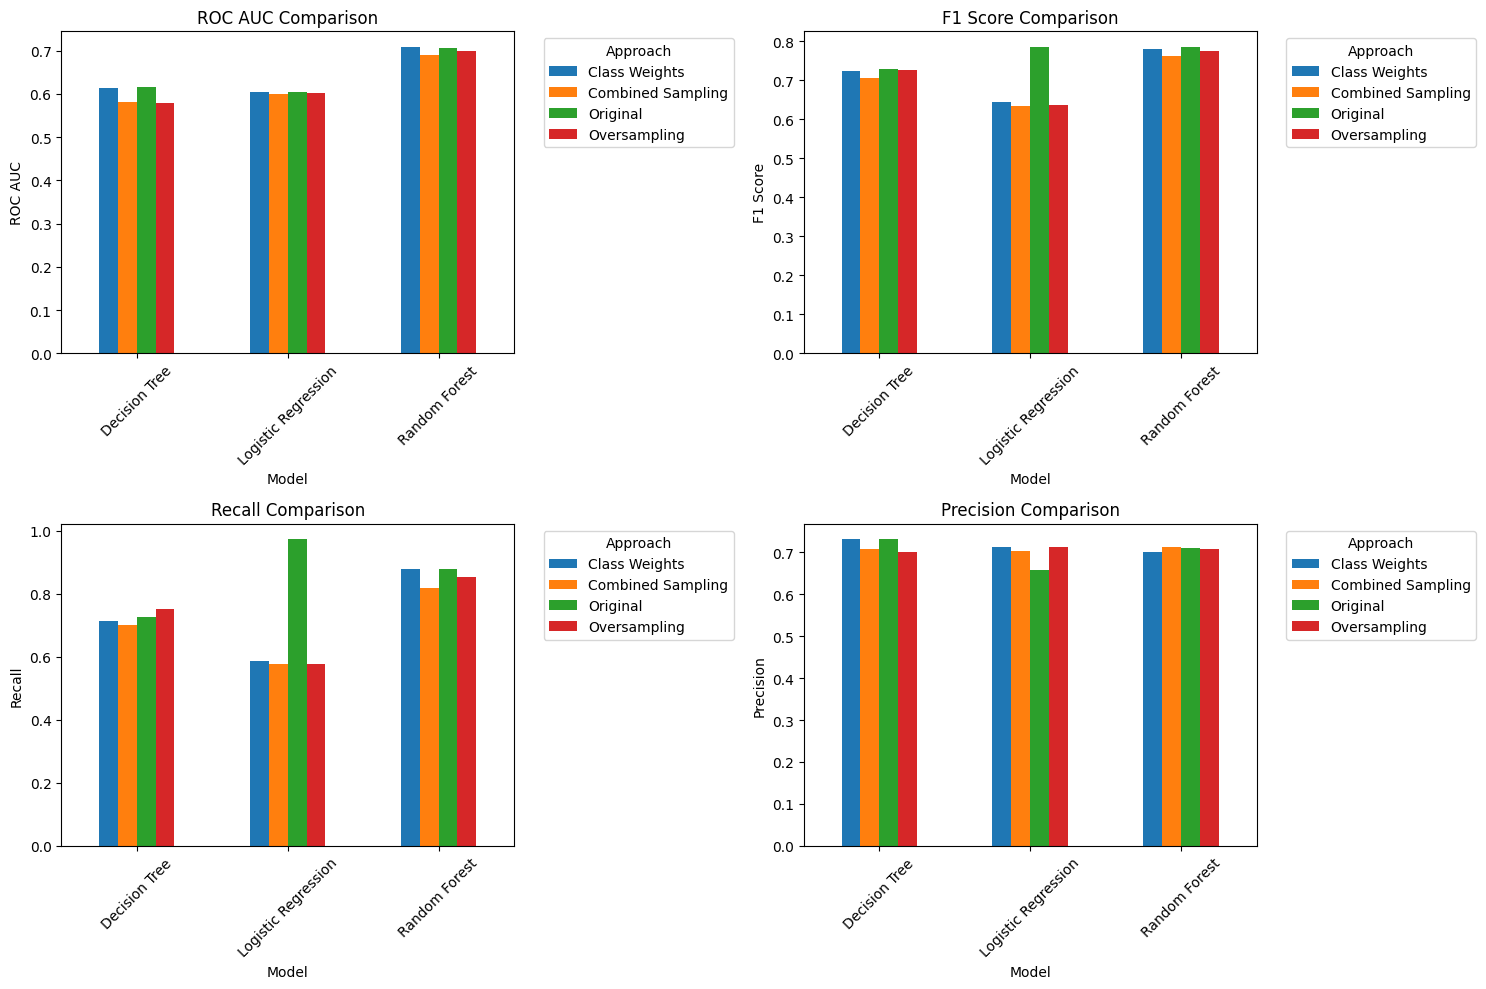


FINAL RECOMMENDATION

Recommended model based on ROC AUC:
- Class Weights with Random Forest
- ROC AUC: 0.7095
- F1 Score: 0.7805
- Recall: 0.8806
- Precision: 0.7008


In [44]:
# Credit Default Prediction without imbalanced-learn library (corrected version)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from category_encoders.target_encoder import TargetEncoder
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
from sklearn.utils import resample

# ==================== STEP 1: REPAIR THE DATA ====================

# Revert wrongly log-transformed columns
columns_to_fix = ['Income', 'TimeEmploymentMM', 'TotalTimeAtAddress']
for col in columns_to_fix:
    final_df[col] = np.expm1(final_df[col])

# Create proper log-transformed copies for modeling
final_df['Log_Income'] = np.log1p(final_df['Income'])
final_df['Log_TimeEmploymentMM'] = np.log1p(final_df['TimeEmploymentMM'])
final_df['Log_TotalTimeAtAddress'] = np.log1p(final_df['TotalTimeAtAddress'])

# ==================== STEP 2: FEATURE SELECTION ====================

# Final modeling features — include transformed versions
model_features = [
    'Age', 'LoanAmount', 'NoChildren', 'LoanPerIncome', 'LoanToEmployment',
    'Log_Income', 'Log_TimeEmploymentMM', 'Log_TotalTimeAtAddress',
    'EducationStatus', 'EmployerState', 'Gender', 'Industry',
    'MaritalStatus', 'ResidentialStatus'
]

# Define feature groups
numerical_columns = [
    'Age', 'LoanAmount', 'NoChildren', 'LoanPerIncome', 'LoanToEmployment',
    'Log_Income', 'Log_TimeEmploymentMM', 'Log_TotalTimeAtAddress'
]

categorical_columns = [
    'EducationStatus', 'EmployerState', 'Gender', 'Industry',
    'MaritalStatus', 'ResidentialStatus'
]

# ==================== STEP 3: SETUP X, y ====================

print("Original Class Distribution:")
print(final_df['DefaultStatus'].value_counts())
print(f"Imbalance Ratio (Default:Non-Default): {final_df['DefaultStatus'].value_counts()[1] / final_df['DefaultStatus'].value_counts()[0]:.2f}")

X = final_df[model_features]
y = final_df['DefaultStatus']

# ==================== STEP 4: TRAIN-TEST SPLIT ====================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTraining set distribution:")
print(f"Non-default (0): {sum(y_train == 0)}")
print(f"Default (1): {sum(y_train == 1)}")

# ==================== STEP 5: PREPROCESSOR ====================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', TargetEncoder(), categorical_columns)
    ]
)

# ==================== STEP 6: MANUAL BALANCING FUNCTION ====================

def balance_dataset(X, y, method='oversample'):
    df_combined = pd.concat([X, y], axis=1)
    df_majority = df_combined[df_combined['DefaultStatus'] == 1]
    df_minority = df_combined[df_combined['DefaultStatus'] == 0]
    
    if method == 'oversample':
        df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
        df_balanced = pd.concat([df_majority, df_minority_upsampled])
        
    elif method == 'undersample':
        df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42)
        df_balanced = pd.concat([df_majority_downsampled, df_minority])
        
    elif method == 'combine':
        target_size = int((len(df_majority) + len(df_minority)) / 2)
        df_majority_downsampled = resample(df_majority, replace=False, n_samples=target_size, random_state=42)
        df_minority_upsampled = resample(df_minority, replace=True, n_samples=target_size, random_state=42)
        df_balanced = pd.concat([df_majority_downsampled, df_minority_upsampled])
    
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
    return df_balanced.drop('DefaultStatus', axis=1), df_balanced['DefaultStatus']

# ==================== STEP 7: EVALUATION FUNCTION ====================

def evaluate_model(name, model, X_train, X_test, y_train, y_test, approach_name):
    print(f"\nTraining {name} with {approach_name}...")

    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    print(f"\n{name} Results:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc:.4f}")
    
    return {
        'Model': name,
        'Approach': approach_name,
        'Confusion Matrix': cm,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': roc
    }

# ==================== STEP 8: DEFINE MODELS ====================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

models_weighted = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
}

# ==================== STEP 9: EVALUATE ALL APPROACHES ====================

all_results = []

# Approach 1: Oversampling
print("\n" + "="*70)
print("APPROACH 1: OVERSAMPLING MINORITY CLASS")
print("="*70)
X_train_over, y_train_over = balance_dataset(X_train, y_train, method='oversample')
for name, model in models.items():
    result = evaluate_model(name, model, X_train_over, X_test, y_train_over, y_test, "Oversampling")
    all_results.append(result)

# Approach 2: Combined Sampling
print("\n" + "="*70)
print("APPROACH 2: COMBINED SAMPLING")
print("="*70)
X_train_combined, y_train_combined = balance_dataset(X_train, y_train, method='combine')
for name, model in models.items():
    result = evaluate_model(name, model, X_train_combined, X_test, y_train_combined, y_test, "Combined Sampling")
    all_results.append(result)

# Approach 3: Class Weights
print("\n" + "="*70)
print("APPROACH 3: CLASS WEIGHTS")
print("="*70)
for name, model in models_weighted.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test, "Class Weights")
    all_results.append(result)

# Approach 4: Original (no balancing)
print("\n" + "="*70)
print("APPROACH 4: ORIGINAL (NO BALANCING)")
print("="*70)
for name, model in models.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test, "Original")
    all_results.append(result)

# ==================== STEP 10: COMPARISON TABLES ====================

print("\n" + "="*70)
print("COMPREHENSIVE PERFORMANCE COMPARISON")
print("="*70)

comparison_df = pd.DataFrame(all_results)
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

for approach in ['Oversampling', 'Combined Sampling', 'Class Weights', 'Original']:
    print(f"\n{approach.upper()} RESULTS:")
    approach_results = comparison_df[comparison_df['Approach'] == approach]
    display_df = approach_results[['Model'] + metrics_cols].set_index('Model')
    print(display_df.round(4))

# ==================== STEP 11: BEST MODEL SUMMARY ====================

print("\n" + "="*70)
print("BEST PERFORMING MODELS")
print("="*70)
for metric in metrics_cols:
    best_idx = comparison_df[metric].idxmax()
    best_result = comparison_df.loc[best_idx]
    print(f"Best {metric}: {best_result['Approach']} - {best_result['Model']} ({best_result[metric]:.4f})")

# ==================== STEP 12: VISUALIZATION ====================

plt.figure(figsize=(15, 10))

for i, metric in enumerate(['ROC AUC', 'F1 Score', 'Recall', 'Precision'], 1):
    plt.subplot(2, 2, i)
    pivot_df = comparison_df.pivot(index='Model', columns='Approach', values=metric)
    pivot_df.plot(kind='bar', ax=plt.gca())
    plt.title(f'{metric} Comparison')
    plt.ylabel(metric)
    plt.legend(title='Approach', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==================== STEP 13: RECOMMENDATION ====================

print("\n" + "="*70)
print("FINAL RECOMMENDATION")
print("="*70)

best_overall = comparison_df.loc[comparison_df['ROC AUC'].idxmax()]
print(f"\nRecommended model based on ROC AUC:")
print(f"- {best_overall['Approach']} with {best_overall['Model']}")
print(f"- ROC AUC: {best_overall['ROC AUC']:.4f}")
print(f"- F1 Score: {best_overall['F1 Score']:.4f}")
print(f"- Recall: {best_overall['Recall']:.4f}")
print(f"- Precision: {best_overall['Precision']:.4f}")


In [45]:
#Creating final model pipeline (Random Forest with class_weight='balanced')
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight='balanced'
    ))
])

In [46]:
final_df.columns

Index(['Age', 'EducationStatus', 'EmployerState', 'Gender', 'Income',
       'Industry', 'LoanAmount', 'MaritalStatus', 'NoChildren',
       'ResidentialStatus', 'TimeEmploymentMM', 'TotalTimeAtAddress',
       'DefaultStatus', 'LoanPerIncome', 'LoanToEmployment', 'Log_Income',
       'Log_TimeEmploymentMM', 'Log_TotalTimeAtAddress'],
      dtype='object')

In [47]:
final_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


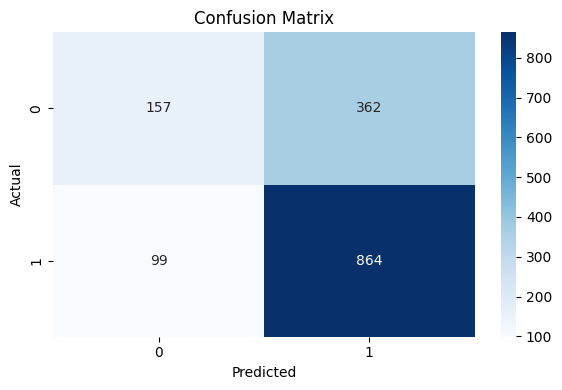


Final Model Evaluation (Random Forest with class weights):
Accuracy     : 0.6889
Precision    : 0.7047
Recall       : 0.8972
F1 Score     : 0.7894
ROC AUC      : 0.7140


In [48]:
# 6. Evaluate final model
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]


# Confusion matrix and metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)


# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Print nicely
print("\nFinal Model Evaluation (Random Forest with class weights):")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {roc:.4f}")



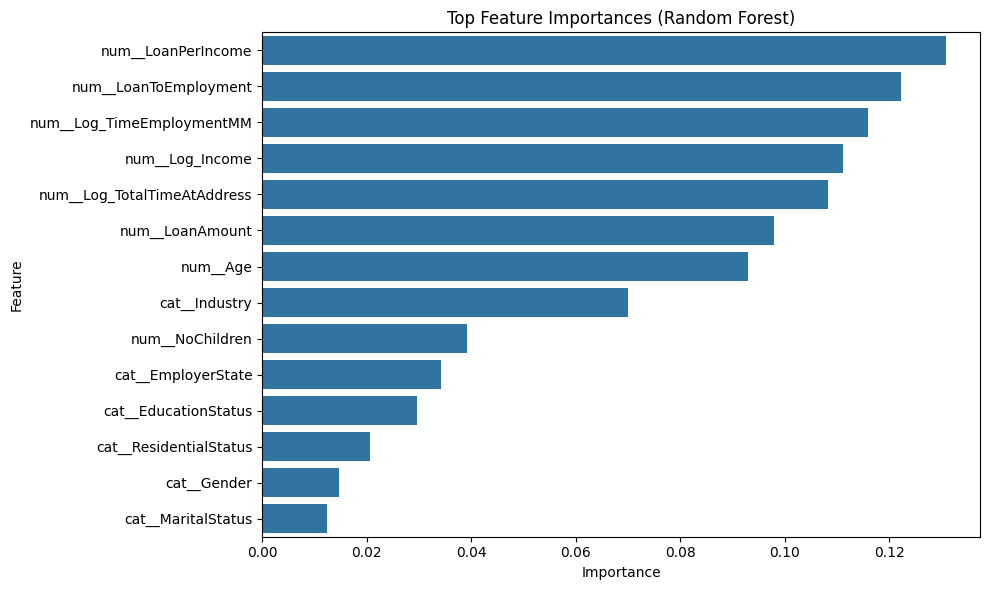

In [49]:
# 7. Feature importance analysis
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
importances = final_model.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


=== Performance with Top 10 Features (log + engineered) ===
Accuracy : 0.6842
Precision: 0.7054
Recall   : 0.8827
F1 Score : 0.7841
ROC AUC  : 0.7110


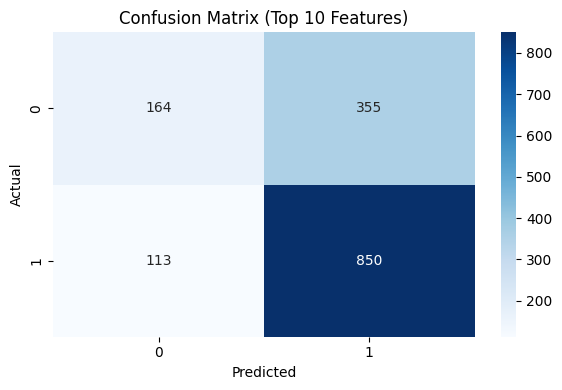

In [50]:
# 1. Feature Engineering in main dataset
import numpy as np
import pandas as pd

# Make a copy to avoid mutation
df_model = final_df.copy()

# Feature engineering: create transformed columns
df_model["LoanPerIncome"] = df_model["LoanAmount"] / (df_model["Income"] + 1e-5)
df_model["LoanToEmployment"] = df_model["LoanAmount"] / (df_model["TimeEmploymentMM"] + 1e-5)
df_model["Log_Income"] = np.log1p(df_model["Income"])
df_model["Log_TimeEmploymentMM"] = np.log1p(df_model["TimeEmploymentMM"])
df_model["Log_TotalTimeAtAddress"] = np.log1p(df_model["TotalTimeAtAddress"])

# 2. Select the final top 10 features based on your pipeline
top_10_features = [
    'LoanPerIncome',
    'LoanToEmployment',
    'Log_TimeEmploymentMM',
    'Log_Income',
    'Log_TotalTimeAtAddress',
    'LoanAmount',
    'Age',
    'Industry',
    'NoChildren',
    'EmployerState',
]

# 3. Separate features and target
X_top10 = df_model[top_10_features]
y = df_model['DefaultStatus']

# 4. Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_top10, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Identify column types
numerical_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 6. Preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from category_encoders.target_encoder import TargetEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', TargetEncoder(), categorical_columns)
    ]
)

# 7. Random Forest Classifier with class weights
from sklearn.ensemble import RandomForestClassifier

model_top10 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=42
    ))
])

# 8. Train model
model_top10.fit(X_train, y_train)

# 9. Evaluate model
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = model_top10.predict(X_test)
y_proba = model_top10.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

# Output
print("=== Performance with Top 10 Features (log + engineered) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc:.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix (Top 10 Features)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


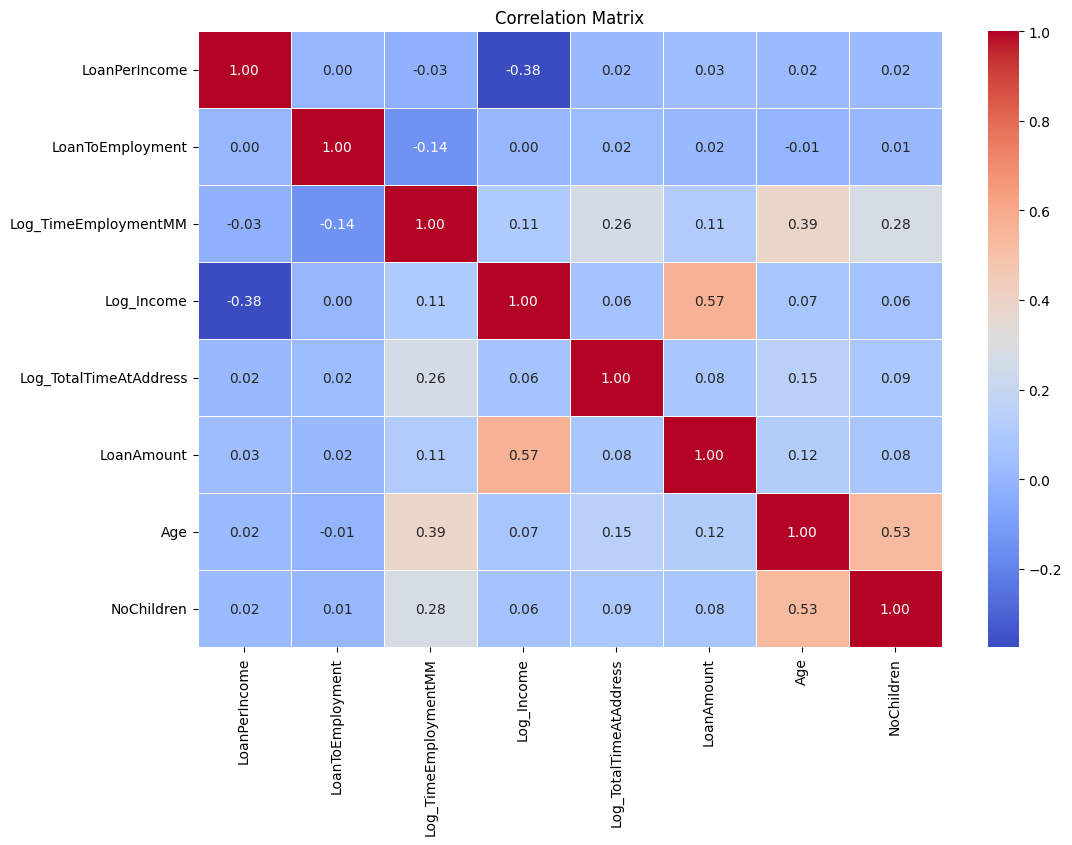

In [51]:
# Compute correlation matrix (only for numeric features)
corr_matrix = X_top10.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

=== ROC-AUC Analysis ===
Area Under the Curve (AUC): 0.7110
Model Performance Interpretation:
  → Fair performance

Key Points on ROC Curve:
False Positive Rate range: 0.000 to 1.000
True Positive Rate range: 0.000 to 1.000


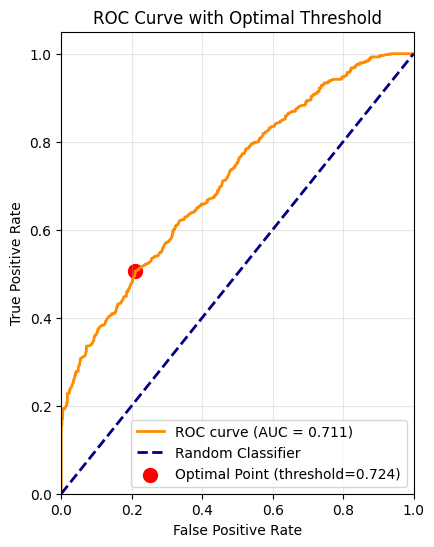

In [52]:
# ROC-AUC Chart for the Top 10 Features Model
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Find optimal threshold (closest to top-left corner)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

# Create a detailed ROC curve with optimal point marked
plt.figure(figsize=(10, 6))

# Plot ROC curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier')
plt.scatter(optimal_fpr, optimal_tpr, color='red', s=100, 
           label=f'Optimal Point (threshold={optimal_threshold:.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Optimal Threshold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


# Print detailed ROC-AUC information
print("=== ROC-AUC Analysis ===")
print(f"Area Under the Curve (AUC): {roc_auc:.4f}")
print(f"Model Performance Interpretation:")
if roc_auc >= 0.9:
    print("  → Excellent performance")
elif roc_auc >= 0.8:
    print("  → Good performance")
elif roc_auc >= 0.7:
    print("  → Fair performance")
elif roc_auc >= 0.6:
    print("  → Poor performance")
else:
    print("  → Very poor performance")

print(f"\nKey Points on ROC Curve:")
print(f"False Positive Rate range: {fpr.min():.3f} to {fpr.max():.3f}")
print(f"True Positive Rate range: {tpr.min():.3f} to {tpr.max():.3f}")



In [53]:
credit_model=model_top10
credit_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
import joblib

# Save the trained model
joblib.dump(credit_model, "credit_model.pkl")


['credit_model.pkl']